# Proyecto Final — Data Science II

# BTC / DXY / Oro / VIX

## Notebook 04 — Adquisición VIX mediante rangos temporales fijos

Curso: Data Science II — Machine Learning para Ciencia de Datos
Coderhouse | 2025–2026

---

Este notebook corresponde a la etapa de adquisición definitiva del índice VIX para el proyecto BTC/DXY/Oro/VIX.

El VIX será utilizado como indicador de volatilidad implícita y aversión al riesgo dentro del mercado financiero estadounidense.

La finalidad de este bloque es construir un dataset reproducible, validado y exportable, manteniendo la misma lógica modular aplicada previamente en los notebooks de BTC, DXY y Oro.

El dataset obtenido en este notebook formará parte de la Fase 1 del pipeline maestro del proyecto y será utilizado posteriormente en la integración multi-activo.

# Contexto metodológico

En los notebooks anteriores se consolidó la estructura base del pipeline modular:

- adquisición mediante rango temporal fijo,
- limpieza estructural del DataFrame,
- validación estructural y temporal,
- construcción de variables iniciales,
- validación de valores faltantes,
- EDA de validación,
- logging básico,
- y export del dataset procesado.

En este notebook se reutiliza esa arquitectura para adquirir y validar datos históricos del índice VIX.

La decisión metodológica principal es mantener consistencia entre activos, utilizando:

- el mismo rango temporal oficial,
- la misma frecuencia diaria,
- una estructura de validación comparable,
- y un output procesado reutilizable para etapas posteriores.

# Rango temporal y fuente de datos

El rango temporal oficial del proyecto será:

| Inicio | Fin |
|---|---|
| 2023-05-06 | 2026-05-06 |

Frecuencia:
- diaria

Fuente:
- Yahoo Finance mediante `yfinance`

Ticker utilizado:
- `^VIX`

---

El ticker `^VIX` corresponde al índice de volatilidad implícita calculado por el CBOE.

El VIX es ampliamente utilizado como indicador de incertidumbre y aversión al riesgo en los mercados financieros, por lo que se incorpora al proyecto como variable macro-financiera complementaria al análisis de Bitcoin.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Adquisición de datos desde Yahoo Finance

Se realizará la descarga histórica del índice VIX mediante Yahoo Finance utilizando el ticker `^VIX`.

La adquisición se realiza con:

- rango temporal fijo,
- frecuencia diaria,
- y datos OHLCV completos.

Esto permite mantener reproducibilidad y consistencia metodológica respecto a los activos adquiridos previamente.

In [2]:
vix_df = yf.download(
    "^VIX",
    start="2023-05-06",
    end="2026-05-07",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [3]:
vix_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2023-05-08,16.980000,17.879999,16.830000,17.730000,0
2023-05-09,17.709999,17.860001,17.219999,17.290001,0
2023-05-10,16.940001,18.309999,16.360001,17.580000,0
2023-05-11,16.930000,18.190001,16.629999,16.799999,0
2023-05-12,17.030001,17.920000,16.379999,16.830000,0


# 2. Exploración inicial de la estructura y aplanamiento del DataFrame

La descarga desde Yahoo Finance genera una estructura de columnas multinivel (MultiIndex), donde el primer nivel representa el tipo de dato financiero y el segundo nivel el ticker consultado.

Dado que este notebook trabaja exclusivamente con un único activo, se elimina el nivel correspondiente al ticker para obtener una estructura de columnas plana y más sencilla de manipular durante las etapas posteriores del pipeline.

In [4]:
vix_df.columns = vix_df.columns.droplevel(1)

In [5]:
vix_df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-08,16.980000,17.879999,16.830000,17.730000,0
2023-05-09,17.709999,17.860001,17.219999,17.290001,0
2023-05-10,16.940001,18.309999,16.360001,17.580000,0
2023-05-11,16.930000,18.190001,16.629999,16.799999,0
2023-05-12,17.030001,17.920000,16.379999,16.830000,0


In [6]:
vix_df.columns.name = None

In [7]:
vix_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

# 3. Validación estructural y temporal del dataset VIX

Antes de continuar con la construcción de features y análisis exploratorio, se realizan validaciones básicas de integridad estructural sobre el dataset adquirido.

Las siguientes verificaciones buscan confirmar:

- consistencia temporal,
- ausencia de duplicados,
- continuidad del rango temporal,
- y coherencia general de la estructura del dataset.

In [8]:
print("=== VALIDACIÓN ESTRUCTURAL VIX ===")

print(f"Shape del dataset: {vix_df.shape}")

print(
    f"Rango temporal: "
    f"{vix_df.index.min().date()} "
    f"→ "
    f"{vix_df.index.max().date()}"
)

print(
    f"Orden cronológico correcto: "
    f"{vix_df.index.is_monotonic_increasing}"
)

print(
    f"Duplicados temporales: "
    f"{vix_df.index.duplicated().sum()}"
)

print(
    f"Gaps temporales detectados: "
    f"{(vix_df.index.to_series().diff().dropna() != pd.Timedelta(days=1)).sum()}"
)

print(
    "Nota: en VIX los gaps temporales son esperados "
    "por calendario financiero (fines de semana y feriados)."
)

=== VALIDACIÓN ESTRUCTURAL VIX ===
Shape del dataset: (752, 5)
Rango temporal: 2023-05-08 → 2026-05-06
Orden cronológico correcto: True
Duplicados temporales: 0
Gaps temporales detectados: 168
Nota: en VIX los gaps temporales son esperados por calendario financiero (fines de semana y feriados).


# 4. Construcción de features iniciales

Se construirán variables básicas sobre el índice VIX con el objetivo de describir su comportamiento temporal y mantener consistencia estructural con los notebooks anteriores.

A diferencia de BTC, DXY y Oro, el VIX no será tratado principalmente como un activo cuyo retorno porcentual sea la variable más relevante. Su valor interpretativo principal está en el nivel del índice, ya que representa la volatilidad esperada del mercado y el costo relativo de la protección frente a movimientos futuros.

Aun así, se construirán las mismas features iniciales utilizadas en los demás activos:

- retorno porcentual diario (`return`),
- volatilidad móvil de 7 días (`volatility_7d`),
- media móvil de 7 días (`ma_7d`).

Estas variables permiten conservar una estructura homogénea entre datasets y facilitar futuras comparaciones durante la integración multi-activo.

### 4.1. Retorno porcentual diario

In [9]:
vix_df["return"] = vix_df["Close"].pct_change()

### 4.2. Volatilidad rolling de 7 días

In [10]:
vix_df["volatility_7d"] = (
    vix_df["return"]
    .rolling(7)
    .std()
)

### 4.3. Media móvil de 7 días

In [11]:
vix_df["ma_7d"] = (
    vix_df["Close"]
    .rolling(7)
    .mean()
)

# 5. Validación de features y valores faltantes

Las features rolling y los retornos porcentuales generan valores faltantes al inicio de la serie debido a la imposibilidad matemática de calcular ventanas previas inexistentes.

Esta validación permite confirmar que:

- los NaN observados son esperados,
- las columnas fueron construidas correctamente,
- y no existen pérdidas anómalas de información.

In [12]:
print("=== VALIDACIÓN DE NaN ===")

print(
    f"NaN en return: "
    f"{vix_df['return'].isna().sum()}"
)

print(
    f"NaN en volatility_7d: "
    f"{vix_df['volatility_7d'].isna().sum()}"
)

print(
    f"NaN en ma_7d: "
    f"{vix_df['ma_7d'].isna().sum()}"
)

=== VALIDACIÓN DE NaN ===
NaN en return: 1
NaN en volatility_7d: 7
NaN en ma_7d: 6


# 6. Visualización del VIX

Se visualiza la evolución temporal del índice VIX dentro del rango oficial del proyecto.

El objetivo de esta visualización es:

- observar el comportamiento general del índice,
- identificar períodos de tensión e incertidumbre,
- detectar cambios relevantes en la percepción de riesgo del mercado,
- y validar coherencia visual de la serie temporal adquirida.

A diferencia de los activos analizados previamente, el VIX no representa un precio de mercado tradicional, sino una medida de volatilidad esperada e incertidumbre financiera.

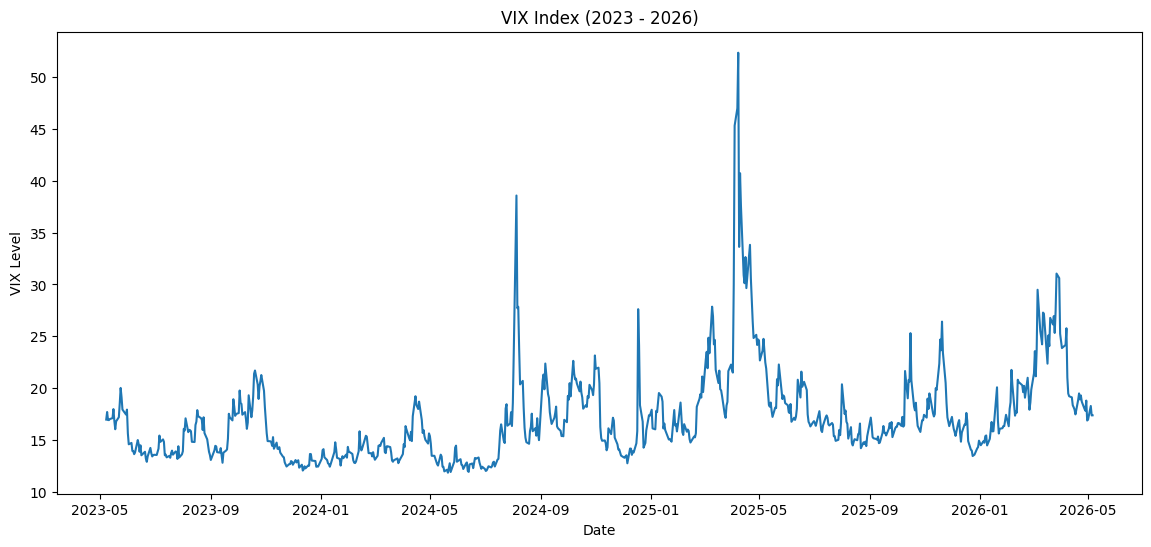

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    vix_df.index,
    vix_df["Close"]
)

plt.title("VIX Index (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("VIX Level")

plt.show()

## Lectura inicial del comportamiento del VIX

La visualización del VIX muestra una dinámica claramente distinta respecto a los demás activos analizados.

A diferencia de Bitcoin y Oro, el VIX no presenta tendencias sostenidas de largo plazo, sino largos períodos de relativa estabilidad interrumpidos por episodios abruptos de tensión e incertidumbre.

Estos picos representan momentos donde el mercado incrementa significativamente la demanda de cobertura y protección frente a posibles movimientos adversos.

Durante gran parte del período analizado el índice permanece en niveles moderados, aunque pueden observarse varios episodios de tensión relevantes, especialmente durante 2024, 2025 y comienzos de 2026.

Esta estructura visual refuerza el rol del VIX como indicador de incertidumbre percibida dentro del sistema financiero y no como un activo financiero tradicional orientado a la generación de retornos.

# 7. Visualización de retornos diarios del VIX

Se visualizan los retornos porcentuales diarios del VIX con el objetivo de observar:

- intensidad de los cambios diarios,
- comportamiento de la volatilidad implícita,
- y posibles episodios de tensión extrema.

Aunque el VIX será utilizado principalmente como nivel dentro del proyecto, los retornos permiten complementar la comprensión de su dinámica temporal.

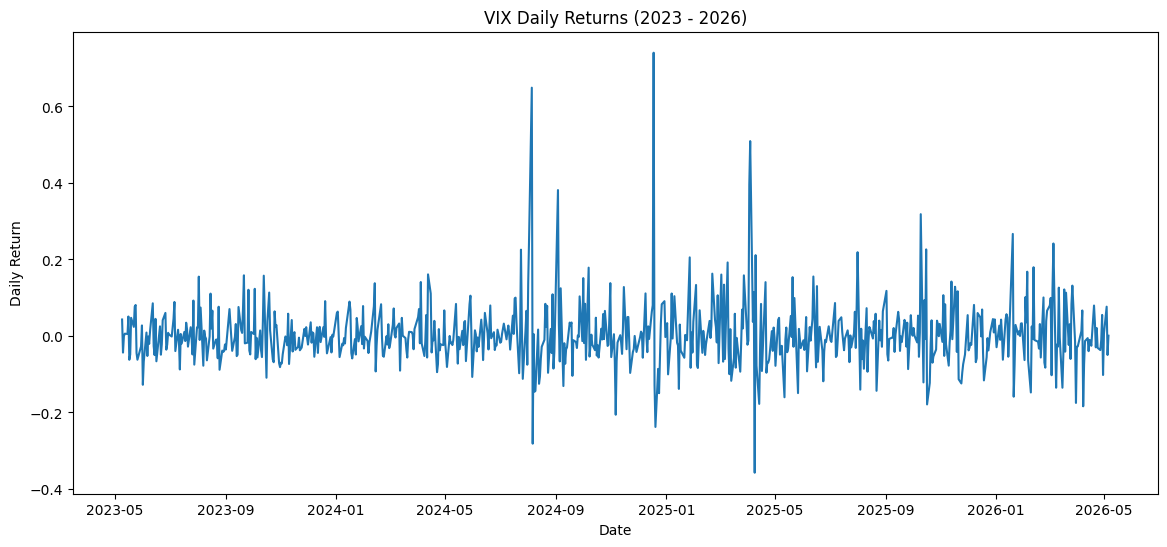

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    vix_df.index,
    vix_df["return"]
)

plt.title("VIX Daily Returns (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

## Lectura inicial de retornos diarios del VIX

Los retornos diarios del VIX presentan una dinámica claramente distinta respecto a los demás activos analizados.

Mientras que Bitcoin, Oro y DXY desarrollan movimientos que pueden extenderse durante períodos relativamente prolongados, el VIX muestra episodios de expansión extremadamente abruptos y generalmente de corta duración.

La mayor parte del tiempo los retornos permanecen relativamente contenidos, pero aparecen spikes aislados de magnitud considerable que reflejan cambios repentinos en la percepción de riesgo del mercado.

A diferencia de la volatilidad observada en otros activos, estos episodios no suelen permanecer elevados durante períodos extensos, sino que tienden a manifestarse como eventos puntuales que posteriormente regresan hacia niveles más normales.

Este comportamiento resulta coherente con la naturaleza del índice, ya que el VIX actúa como una medida de incertidumbre percibida y demanda de protección financiera, reaccionando rápidamente ante eventos relevantes y normalizándose una vez que el mercado procesa la nueva información.

La presencia de estos picos constituye una característica distintiva del VIX y será especialmente relevante durante la integración multi-activo, donde se analizará su relación temporal con los movimientos observados en BTC, Oro y DXY.

# 8. Volatilidad móvil de 7 días

Se visualiza la volatilidad móvil de 7 días del VIX con el objetivo de identificar:

- períodos de mayor incertidumbre financiera,
- cambios en intensidad de movimiento,
- y posibles regímenes temporales de tensión.

La volatilidad rolling permite observar cómo evoluciona la dispersión de los retornos a lo largo del tiempo y complementa la interpretación de los movimientos diarios del índice.

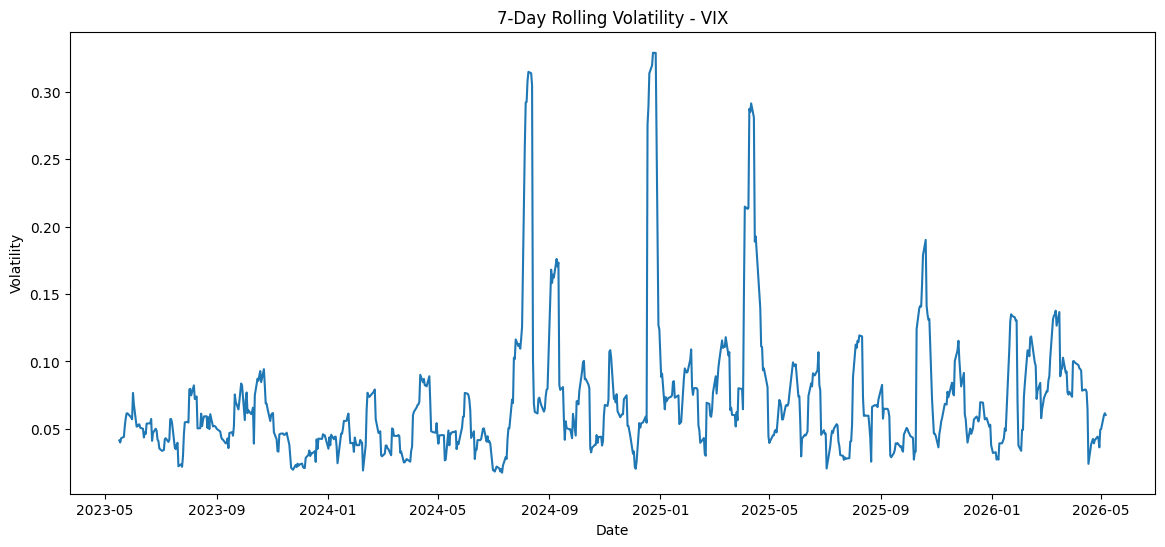

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    vix_df.index,
    vix_df["volatility_7d"]
)

plt.title("7-Day Rolling Volatility - VIX")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Lectura inicial de volatilidad móvil del VIX

La volatilidad móvil de 7 días permite observar que los episodios de incertidumbre extrema del VIX no son completamente instantáneos.

Aunque los retornos diarios muestran spikes muy abruptos y de corta duración, la volatilidad rolling evidencia que estos eventos suelen extenderse durante varios días antes de regresar a niveles más normales.

Los principales períodos de tensión observados durante 2024, 2025 y comienzos de 2026 permanecen claramente identificables luego del suavizado, indicando que no se trata únicamente de movimientos aislados, sino de episodios donde la percepción de riesgo se mantuvo elevada durante un período breve pero significativo.

Sin embargo, estos regímenes de tensión continúan siendo considerablemente más cortos que los observados previamente en el Oro, reforzando la idea de que el VIX funciona como un indicador altamente reactivo a cambios en la incertidumbre financiera.

Esta característica diferencia al VIX tanto de los activos financieros tradicionales como de los activos refugio, posicionándolo como una variable particularmente útil para detectar episodios de estrés dentro del sistema financiero.

# 9. Media móvil de 7 días

Se visualiza la media móvil de 7 días del VIX con el objetivo de suavizar fluctuaciones diarias y observar con mayor claridad el comportamiento general del índice.

La media móvil permite identificar:

- cambios progresivos en la percepción de riesgo,
- fases de aumento o reducción de incertidumbre,
- y períodos donde el mercado permanece relativamente estable.

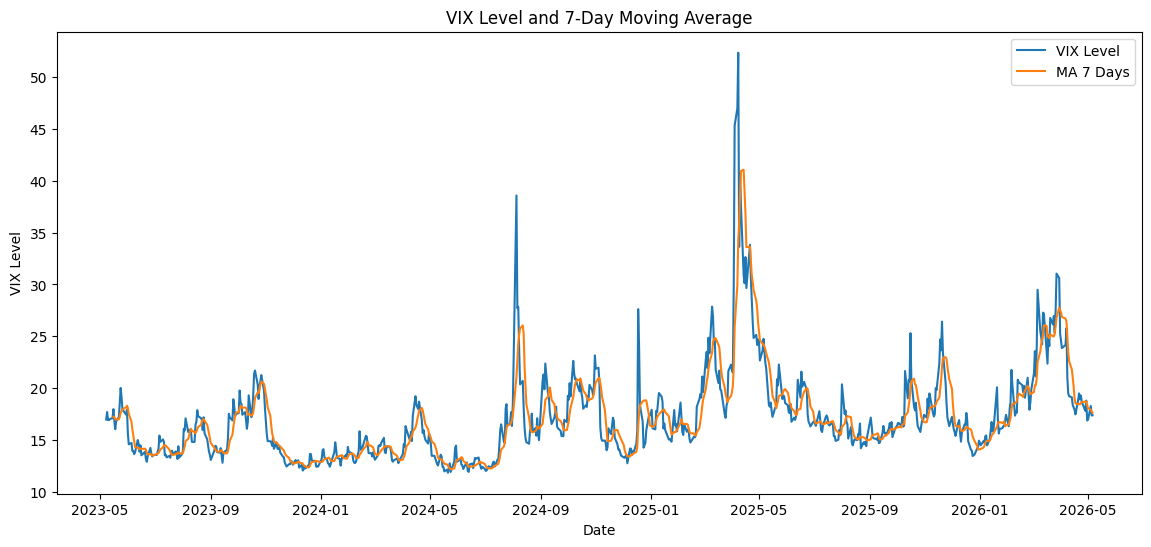

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    vix_df.index,
    vix_df["Close"],
    label="VIX Level"
)

plt.plot(
    vix_df.index,
    vix_df["ma_7d"],
    label="MA 7 Days"
)

plt.title("VIX Level and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("VIX Level")

plt.legend()

plt.show()

## Lectura inicial de la media móvil del VIX

La media móvil de 7 días permite observar con mayor claridad la dinámica general del índice VIX y suavizar parte del ruido presente en las observaciones diarias.

A diferencia de los activos financieros tradicionales analizados previamente, el VIX no muestra tendencias prolongadas de apreciación o depreciación, sino una sucesión constante de períodos de calma relativa e incrementos temporales de incertidumbre.

Si bien los eventos extremos continúan siendo claramente visibles, la media móvil revela además numerosos episodios de tensión moderada que resultan menos evidentes en la serie original debido a la presencia de picos de gran magnitud.

Esto sugiere que la incertidumbre financiera no aparece únicamente durante eventos excepcionales, sino que fluctúa de manera continua alrededor de un nivel basal de preocupación del mercado.

En comparación con Bitcoin, cuya evolución suele estar dominada por tendencias y ciclos de precio, el VIX se comporta más como un indicador de sensibilidad al riesgo, reaccionando constantemente a cambios en las expectativas de los participantes del mercado.

Esta característica refuerza su utilidad como variable complementaria dentro del análisis multi-activo, permitiendo incorporar información relacionada con la percepción agregada de incertidumbre financiera.

# 10. Export del dataset procesado

Luego de finalizar la adquisición, validación y construcción inicial de features, el dataset procesado del VIX será exportado hacia la carpeta `data/processed/`.

Este archivo funcionará como input reutilizable para las siguientes etapas del pipeline multi-activo del proyecto.

In [17]:
import os

PROJECT_PATH = r"C:\DS2_BTC_DXY_ORO_VIX"

processed_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

os.makedirs(processed_path, exist_ok=True)

vix_df.to_csv(
    os.path.join(
        processed_path,
        "vix_processed.csv"
    ),
    encoding="utf-8-sig"
)

print("=== EXPORT FINALIZADO ===")

print("Archivo exportado correctamente hacia:")

print(
    os.path.join(
        processed_path,
        "vix_processed.csv"
    )
)

=== EXPORT FINALIZADO ===
Archivo exportado correctamente hacia:
C:\DS2_BTC_DXY_ORO_VIX\data\processed\vix_processed.csv
